# Winds

In [1]:
import xarray as xr
from tqdm import tqdm 
import glob
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.ndimage import binary_erosion, binary_dilation

In [2]:
lati1,lati2=-4,-17
mask_km = 250

# Theory

## **Wind Speed at Staggered Grid Points**

The wind speed magnitude at u-points (east-west faces) and v-points (north-south faces) is computed by interpolating the perpendicular component and applying:

$$
\text{ws}_u = \sqrt{u^2 + v_{\text{on\_u}}^2}, \quad \text{ws}_v = \sqrt{u_{\text{on\_v}}^2 + v^2}
$$

where $v_{\text{on\_u}}$ is $v$ averaged to u-points in the $\xi$ (longitude) direction, and $u_{\text{on\_v}}$ is $u$ averaged to v-points in the $\eta$ (latitude) direction.

## **Surface Wind Stress**

Wind stress components at the staggered grid faces are computed using the bulk formula:

$$
\tau_x^{(u)} = \rho_{\text{air}}\, C_d\, \text{ws}_u \cdot u, \quad \tau_y^{(v)} = \rho_{\text{air}}\, C_d\, \text{ws}_v \cdot v
$$

where:
- $\rho_{\text{air}} = 1.22\,\text{kg}\,\text{m}^{-3}$ is air density,
- $C_d = 1.3 \times 10^{-3}$ is the drag coefficient.

These are then averaged to the rho-points (cell centers):

$$
\tau_x^{(\rho)} = \frac{1}{2}\left(\tau_x^{(u)}_{i} + \tau_x^{(u)}_{i+1}\right), \qquad \tau_y^{(\rho)} = \frac{1}{2}\left(\tau_y^{(v)}_{j} + \tau_y^{(v)}_{j+1}\right)
$$

## **Grid Metrics (Δx, Δy)**

Horizontal grid spacings on the spherical Earth (radius $A = 6{,}371{,}000\,\text{m}$) are:

$$
\Delta x = A\,\cos(\phi)\,\Delta\lambda, \quad \Delta y = A\,\Delta\phi
$$

where $\phi$ is latitude (radians), $\lambda$ is longitude (radians), and $\Delta\lambda$, $\Delta\phi$ are finite differences along $\xi$ and $\eta$ directions.

## **Curl of Wind Stress**

The vertical component of the curl (vorticity of the wind stress) is computed via centered finite differences:

$$
\nabla \times \boldsymbol{\tau} = \frac{\partial \tau_y}{\partial x} - \frac{\partial \tau_x}{\partial y}
$$

Discretized on the interior cell centers:

$$
\bigl(\nabla \times \boldsymbol{\tau}\bigr)_{i,j} = \frac{\tau_y^{(\rho)}_{i+1,j} - \tau_y^{(\rho)}_{i,j}}{\Delta x_{i,j}} - \frac{\tau_x^{(\rho)}_{i,j+1} - \tau_x^{(\rho)}_{i,j}}{\Delta y_{i,j}}
$$

### **Coriolis Parameter**

The Coriolis parameter at cell centers is:

$$
f = 2\,\Omega\,\sin(\phi)
$$

where $\Omega = 7.2921 \times 10^{-5}\,\text{rad}\,\text{s}^{-1}$ is Earth's angular velocity, and $\phi$ is the latitude averaged over the four surrounding rho-points. Values where $|f| < 10^{-10}$ (near the equator) are set to NaN to avoid division by zero.

## **Ekman Pumping Velocity**

The vertical Ekman pumping velocity (positive upward) at the base of the Ekman layer is:

$$
w_{\text{Ek}} = \frac{1}{\rho_w\,f}\,\bigl(\nabla \times \boldsymbol{\tau}\bigr)_z
$$

where $\rho_w = 1025\,\text{kg}\,\text{m}^{-3}$ is seawater density.

## **Cell Area**

The area of each interior cell (for spatial integrals) is:

$$
A_{\text{cell}} = \Delta x \cdot \Delta y
$$

computed at the curl centers by averaging the edge spacings from neighboring cells.

## U ekman cross-shore offshore part
* For the U ekman Cross-shore ($U^{ekman}_{cross-shore}$) we need to grab the offshore boundary.
* Let's give the distance from the coast to the boundary as $L$

### We make some Assumptions

* Alongshore wind stress drives cross-shore Ekman transport in the surface boundary layer of depth δE
* Coordinates: x is offshore (positive seaward), y is alongshore, z is vertical upward with z=0 at the surface and z=−δE at the Ekman base.
* Steady, Boussinesq, hydrostatic, horizontally uniform along y, negligible alongshore pressure gradient within the Ekman layer.
* No vertical turbulent stress at the Ekman base: τy(z=−δE)=0; at surface: τy(z=0)=τy0.
* No-normal-flow at the coast (x=0): u=0. The offshore boundary is at x=L, where the Ekman layer outcrops into the interior; w(x=L, z=−δE)=0.

### Definitions and Assumptions
We consider a surface Ekman layer of depth $\delta_E$.

Coordinates: $x$ offshore, $y$ alongshore, $z$ upward with $z=0$ at the surface and $z=-\delta_E$ at the Ekman base.

Surface stress $\tau_y(0)=\tau_{y0}$, and $\tau_y(-\delta_E)=0$.

Assume steady Boussinesq flow and $w(0)=0$ (after removing surface waves).

### Ekman transport for momentum balance

$$
fu \;=\; \frac{1}{\rho}\,\frac{\partial \tau_y}{\partial z}
$$

Define the transport per unit width
$$
M_E \;\equiv\; \int_{-\delta_E}^{0} u\,dz.
$$

Integrate in $z$:
$$
\int_{-\delta_E}^{0} fu\,dz
= \frac{1}{\rho}\big[\tau_y\big]_{-\delta_E}^{0}
= \frac{\tau_{y0}}{\rho}
\;\;\Rightarrow\;\;
f\,M_E \;=\; \frac{\tau_{y0}}{\rho}
\;\;\Rightarrow\;\;
M_E \;=\; \frac{\tau_{y0}}{\rho f}.
$$

### Continuity and relation to w at the Ekman base

Incompressibility:
$$
\frac{\partial u}{\partial x}+\frac{\partial w}{\partial z}=0.
$$

Integrate from $z=-\delta_E$ to $z=0$:
$$
\frac{\partial}{\partial x}\!\left(\int_{-\delta_E}^{0}u\,dz\right)
+\Big[w\Big]_{-\delta_E}^{0}=0
\;\;\Rightarrow\;\;
\frac{\partial M_E}{\partial x}=w(-\delta_E)-w(0).
$$

With $w(0)=0$:
$$
w(-\delta_E)=\frac{\partial M_E}{\partial x}.
$$

### Coastal control volume and equivalence
Integrate in $x$ from the coast $x=0$ (no-normal-flow $\Rightarrow M_E(0)=0$) to $x=L$:
$$
M_E(L)-M_E(0)=\int_{0}^{L} w(-\delta_E)\,dx
\;\;\Rightarrow\;\;
M_E(L)=\int_{0}^{L} w_b\,dx,
$$
where $w_b\equiv w(-\delta_E)$ and, if approximately uniform over $[0,L]$,
$$
M_E(L)=w_b\,L.
$$

Using $M_E(L)=\dfrac{\tau_{y0}}{\rho f}$ gives
$$
w_b\,L=\frac{\tau_{y0}}{\rho f}
\quad\Rightarrow\quad
\boxed{\,w_b=\dfrac{1}{L}\,\dfrac{\tau_{y0}}{\rho f}\, }.
$$

Then we need to calculate the $Ek_{t}$ at the offshore part of $L$ as it is the equivalent of the $w_b$

Then let $Ek_c$ be:

\begin{equation}
\tau_{\text{alongshore}} = \sin(\alpha)\,\tau_{y} + \cos(\alpha)\,\tau_{x}
\end{equation}

# Functions

In [3]:
# mask
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [4]:
def get_boundary_lons(ds, var='WMLD', target_width_km=111, lon_slice=None, lat_slice=None,single_time=True):
    """
    Applies coastal masking, spatial slicing, and calculates boundary longitudes.
    
    Parameters:
    ds: xarray.Dataset or DataArray
    var: str, variable name to analyze
    target_width_km: int, width for the coastal_band_mask
    lon_slice: slice, e.g., slice(-85, None)
    lat_slice: slice, e.g., slice(-17, -4)
    """
    # 1. Apply the coastal band mask (assuming this function is defined in your environment)
    mask = coastal_band_mask(ds, var=var, target_width_km=target_width_km)
    
    # 2. Select region and apply mask
    # We slice first, then mask to keep the operations light
    ds_subset = ds.sel(lon=lon_slice, lat=lat_slice)

    # We check if 'time' is in the dimensions before trying to slice it
    if single_time and 'time' in ds_subset.dims:
        data = ds_subset[var].where(mask).isel(time=0)
    else:
        data = ds_subset[var].where(mask)

    
    # 3. Vectorized boundary finding
    valid = data.notnull()
    
    # Find edges using shift
    valid_e = valid.shift(lon=-1).fillna(False)
    valid_w = valid.shift(lon=1).fillna(False)
    
    coast_mask = valid & (~valid_e)      # Easternmost valid cell
    offshore_mask = valid & (~valid_w)   # Westernmost valid cell
    
    # Extract longitudes
    coast_lons = data.lon.where(coast_mask).min(dim='lon')
    offshore_lons = data.lon.where(offshore_mask).min(dim='lon')
    
    return coast_lons, offshore_lons

In [5]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Dataset

In [6]:
winds_ds = xr.open_dataset('../winds_NHUS.nc').compute()
winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

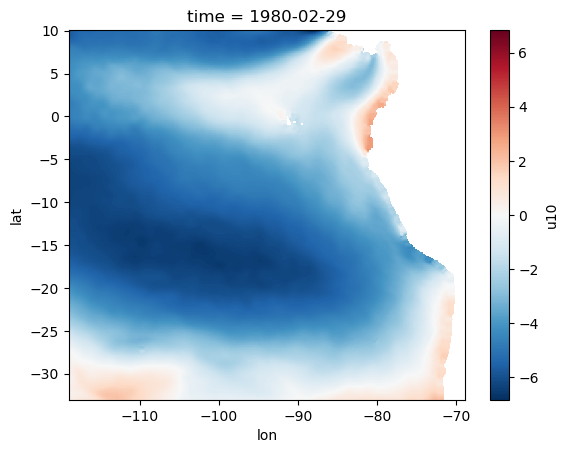

In [7]:
winds_ds.isel(time=1).u10.plot()

## Coastal angle calculation

## Uekman calculation

In [8]:
ws = np.sqrt(winds_ds.u10**2 + winds_ds.v10**2)
omega = 7.29e-5
f = 2 * omega * np.sin(np.radians(winds_ds.lat))
pa = 1.22
cd = 1.3e-3
taux = pa * cd * ws * winds_ds.u10
tauy = pa * cd * ws * winds_ds.v10

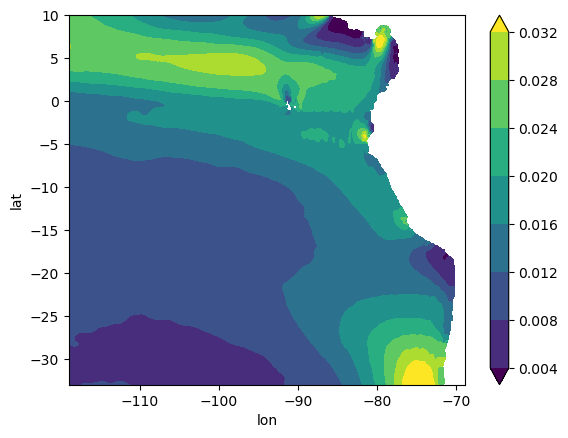

In [9]:
tauy.std('time').plot.contourf(robust=True)

In [10]:
mask = coastal_band_mask(winds_ds, 'u10', mask_km)

In [11]:
wind_coastal = winds_ds.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1)) 
wind_coastal# applies to all variables

<xarray.Dataset> Size: 213MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan
    v10      (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

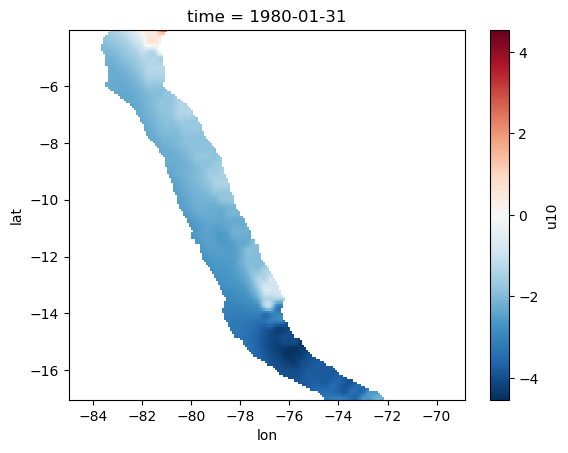

In [12]:
wind_coastal.u10.isel(time=0).plot()

## Ekman transport
* Ekman transport or Uekman or BUI
* offshore at the last cell at 111km
* Inshore for Wc (AV) first cell at $x=0$

In [13]:
rho_sw = 1025


## Comparison with Modelled W

In [14]:
wmld = xr.open_dataset('../W_mld_Croco.nc')
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
wmld

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

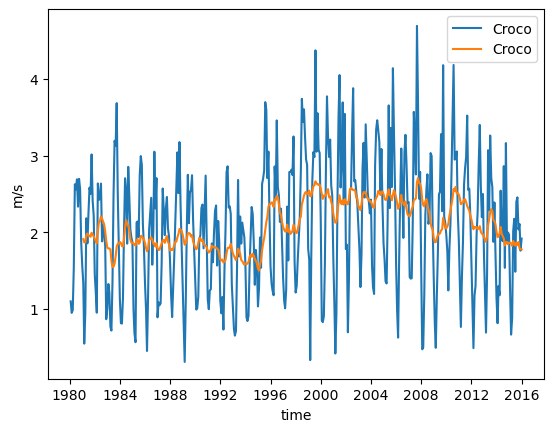

In [15]:
# wmld.WMLD.isel(time=0).plot()
(wmld*mask_km*1000).WMLD.mean(dim=('lat','lon')).rename('m/s').plot(label='Croco')

(wmld*mask_km*1000).WMLD.mean(dim=('lat','lon')).rolling(time=13).mean().rename('m/s').plot(label='Croco')
plt.legend()

In [16]:
# Assuming 'wmld' is your dataset/dataarray
wmld = wmld.assign_coords(
    year=wmld.time.dt.year,
    month=wmld.time.dt.month
)
wmld_ = wmld.set_index(time=['year', 'month']).unstack('time')


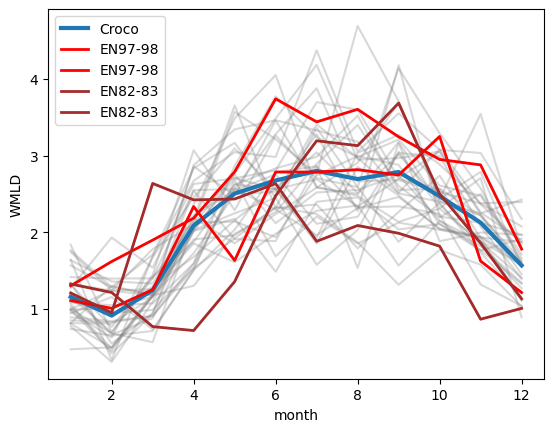

In [17]:
data = (wmld_*mask_km*1000).mean(dim=('lat','lon')).WMLD

data.plot(
    x='month', 
    hue='year',      # This keeps the lines separated by year
    add_legend=False, # This hides the legend
    color='gray',
    alpha=0.3# This may be overridden by the hue cycle, see note below
)

seasonality(wmld*mask_km*1000).WMLD.mean(dim=('lat','lon')).rename('m2/s').plot(label='Croco',linewidth=3)
# 3. Plot highlighted years (Red for 1997-1998)
data.sel(year=[1997,1998]).plot(x='month', hue='year',color='red', linewidth=2,label='EN97-98')

# 4. Plot highlighted years (Brown for 1982-1983)
data.sel(year=[1982, 1983]).plot(x='month',hue='year', color='brown', linewidth=2,label='EN82-83')

plt.legend()

Text(0, 0.5, 'WMLD (Units)')

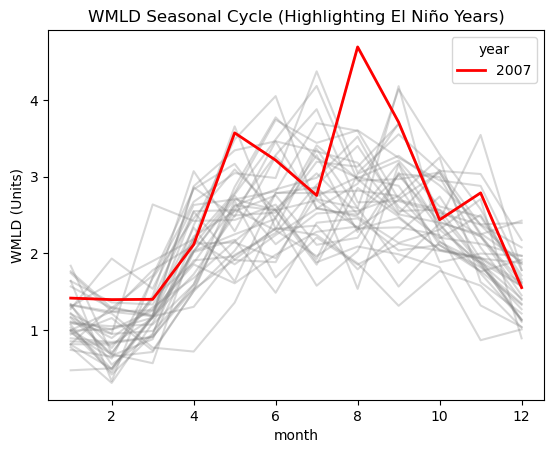

In [18]:
import matplotlib.pyplot as plt

# 1. Prepare the data
# We compute() the mean to keep the plot call fast
data = (wmld_*mask_km*1000).mean(dim=('lat','lon')).WMLD

# 2. Plot background (all years in gray)
data.plot(x='month', hue='year', add_legend=False, color='gray', alpha=0.3)

# 3. Plot highlighted years (Red for 1997-1998)
data.sel(year=[2007]).plot(x='month', hue='year',color='red', linewidth=2)

# 4. Plot highlighted years (Brown for 1982-1983)
# data.sel(year=[1982, 1983]).plot(x='month',hue='year', color='brown', linewidth=2)

# Optional: Add titles or labels
plt.title("WMLD Seasonal Cycle (Highlighting El Niño Years)")
plt.ylabel("WMLD (Units)")

* Winds blow stronger during the austral winter, and BUI captures the wind effect. Croco includes the u geostrophic that can contrarest the winds
* BUI is very sensitive to the angle and the L, we recommend to take the median instead of the mean

## Ekman geographic

In [19]:
winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

In [22]:
winds_ds['Uek_geo'] = tauy/(rho_sw*f)
winds_ds['Vek_geo'] = -taux/(rho_sw*f)
winds_ds['f'] = f
# winds_ds.to_netcdf('winds_and_components_corrected.nc')

In [21]:
winds_ds_ = winds_ds.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))

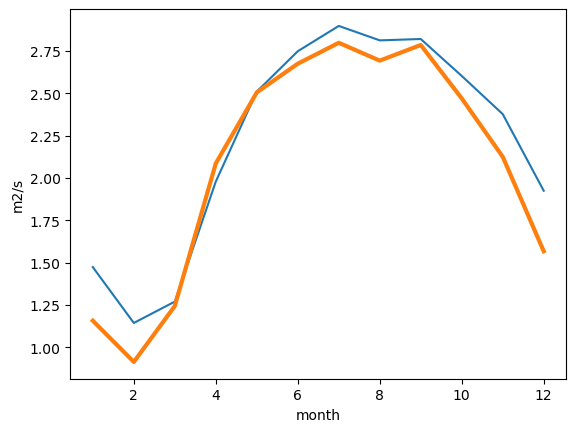

In [22]:
seasonality(winds_ds_.Uek_geo.mean(dim=('lat','lon'))*-1).plot()
seasonality(wmld*mask_km*1000).WMLD.mean(dim=('lat','lon')).rename('m2/s').plot(label='Croco',linewidth=3)


# Ekman Pumping

In [23]:
from tqdm import tqdm

A = 6371000.0
rho_air = 1.22
Cd = 1.3e-3
rho_w = 1025.0
Omega = 7.2921e-5

In [24]:
delta_y = np.deg2rad(winds_ds.lat.shift(lat=-1) - winds_ds.lat) * A
delta_x = (
    np.deg2rad(winds_ds.lon.shift(lon=-1) - winds_ds.lon) * A
    * np.cos(np.deg2rad(winds_ds.lat))
)

dtauy_by_dx = (tauy.shift(lon=-1) - tauy) / delta_x
dtauy_by_dx = (dtauy_by_dx.shift(lat=-1) + dtauy_by_dx) / 2.0

dtaux_by_dy = (taux.shift(lat=-1) - taux) / delta_y
dtaux_by_dy = (dtaux_by_dy.shift(lon=-1) + dtaux_by_dy) / 2.0

lon1 = (winds_ds.lon.shift(lon=-1) + winds_ds.lon) / 2
lat1 = (winds_ds.lat.shift(lat=-1) + winds_ds.lat) / 2

dtaux_by_dy = dtaux_by_dy.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))
dtauy_by_dx = dtauy_by_dx.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))

curlz_tau = (dtauy_by_dx - dtaux_by_dy)

f = 2 * 7.2921e-5 * np.sin(np.deg2rad(curlz_tau.lat))
rho = 1025

w_ek = (1/f/rho) * curlz_tau

w_ek = w_ek.transpose('time','lat','lon')
w_ek

<xarray.DataArray (time: 432, lat: 541, lon: 601)> Size: 1GB
array([[[ 2.72424435e-07,  3.15049249e-07,  3.46992220e-07, ...,
                     nan,             nan,             nan],
        [ 2.69494222e-07,  3.09872783e-07,  3.36117293e-07, ...,
                     nan,             nan,             nan],
        [ 2.60582631e-07,  2.96705216e-07,  3.16600183e-07, ...,
                     nan,             nan,             nan],
        ...,
        [-1.07519679e-07, -2.09001497e-07, -1.86646631e-07, ...,
                     nan,             nan,             nan],
        [-2.38697647e-07, -3.32612218e-07, -3.11489473e-07, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 2.49513510e-07,  2.39869719e-07,  2.24505258e-07, ...,
                     nan,             nan,             nan],
        [ 2.40636757e-07,  2.26566192e-07,  2.10605824e-07, ...,
                     nan,             nan,             nan],
        [ 2.27014849e-07,  2.11650754e-07,  1.98003447e-07, ...,
                     nan,             nan,             nan],
...
        [ 1.94535802e-08,  1.85697773e-08,  2.42230336e-08, ...,
                     nan,             nan,             nan],
        [ 4.55052992e-09,  3.81081672e-09,  8.18491203e-09, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 4.16830108e-08,  4.67495481e-08,  4.91892179e-08, ...,
                     nan,             nan,             nan],
        [ 3.94522591e-08,  4.50353188e-08,  4.84285871e-08, ...,
                     nan,             nan,             nan],
        [ 3.94275450e-08,  4.64486001e-08,  5.14865957e-08, ...,
                     nan,             nan,             nan],
        ...,
        [ 7.74884637e-06,  7.68380580e-06,  7.74123803e-06, ...,
                     nan,             nan,             nan],
        [ 7.73282744e-06,  7.72981215e-06,  7.84915310e-06, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91

In [25]:
w_ek = w_ek.to_dataset(name = 'w_ek').transpose('time','lat','lon')
print(w_ek)

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 541, time: 432, lon: 601)
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91
Data variables:
    w_ek     (time, lat, lon) float64 1GB 2.724e-07 3.15e-07 ... nan nan


In [26]:
mask_pump = coastal_band_mask(w_ek, 'w_ek', mask_km)

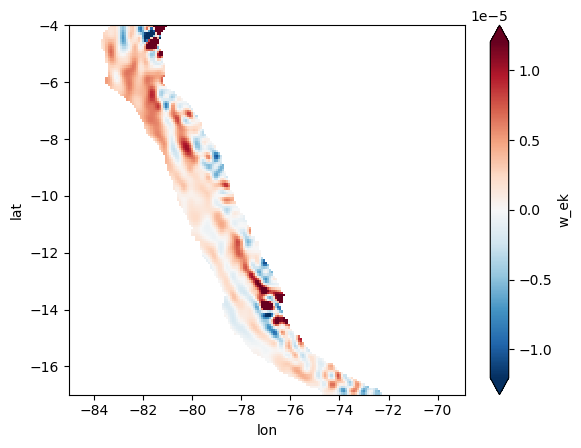

In [27]:
w_ek.where(mask_pump).w_ek.sel(lon=slice(-85,None),lat=slice(lati2,lati1)).mean('time').plot(robust=True)

In [30]:
# w_ek.to_netcdf('Ekman_pumping.nc')